In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Lets Import Datasets now

In [3]:
trades = pd.read_csv("data/historical_data.csv")
sentiment = pd.read_csv("data/fear_greed_index.csv")

In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Dataset Dimentions

In [6]:
print("Trades Dataset Shape:", trades.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

Trades Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


Missing Values

In [7]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Records

In [9]:
print("Trade duplicates:", trades.duplicated().sum())
print("Sentiment duplicates:", sentiment.duplicated().sum())

Trade duplicates: 0
Sentiment duplicates: 0


There are no duplicates so now lets start timestamp conversation

In [10]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [11]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

In [12]:
sentiment['date'] = pd.to_datetime(
    sentiment['date']
)

In [13]:
trades['date'] = trades['date'].dt.date
sentiment['date'] = sentiment['date'].dt.date

Now lets merge datasets

In [14]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='inner'
)

This is merged dataset :-

In [15]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


Now lets add the requested features

In [16]:
merged['win'] = merged['Closed PnL'] > 0

In [17]:
merged['is_long'] = merged['Side'] == 'BUY'
merged['is_short'] = merged['Side'] == 'SELL'

In [18]:
daily_pnl = merged.groupby(
    'date'
)['Closed PnL'].sum()

In [19]:
daily_trades = merged.groupby(
    'date'
).size()

In [20]:
daily_winrate = merged.groupby(
    'date'
)['win'].mean()

In [21]:
avg_trade_size = merged.groupby(
    'date'
)['Size USD'].mean()

In [23]:
longs = merged.groupby(
    'date'
)['is_long'].sum()

shorts = merged.groupby(
    'date'
)['is_short'].sum()

long_short_ratio = longs / shorts

Visual Analysis

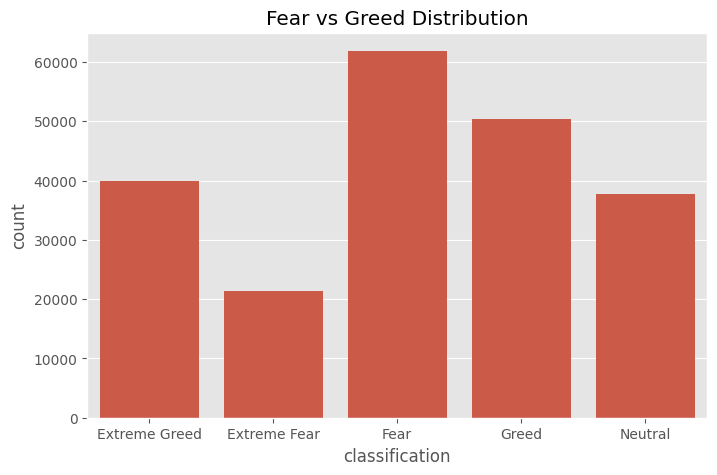

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='classification',
    data=merged
)

plt.title("Fear vs Greed Distribution")

plt.show()

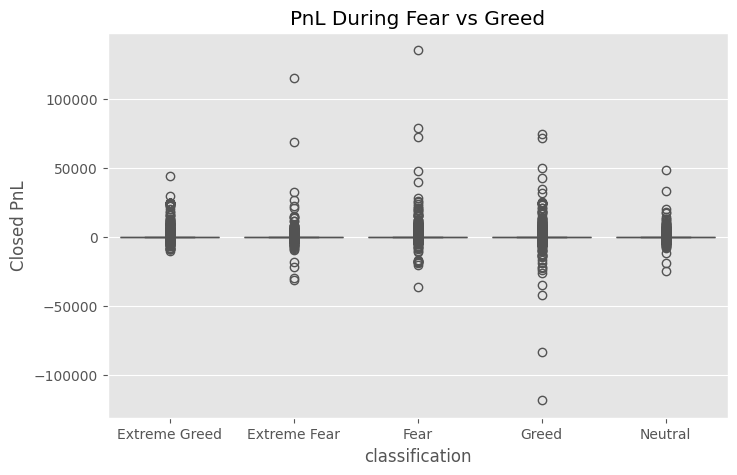

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("PnL During Fear vs Greed")

plt.show()

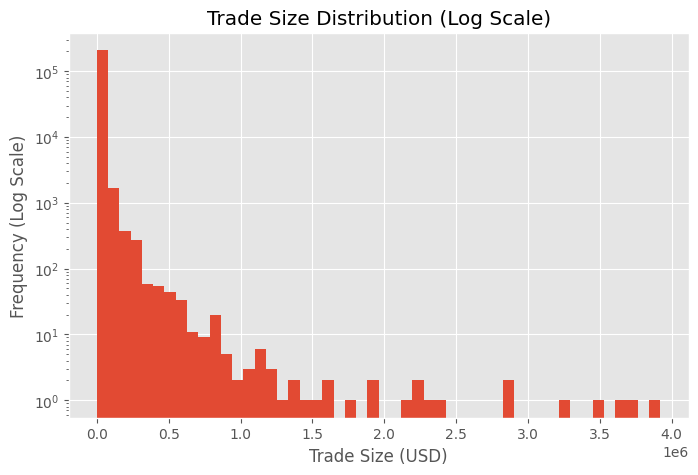

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    merged['Size USD'],
    bins=50,
    log=True
)

plt.title("Trade Size Distribution (Log Scale)")

plt.xlabel("Trade Size (USD)")
plt.ylabel("Frequency (Log Scale)")

plt.show()

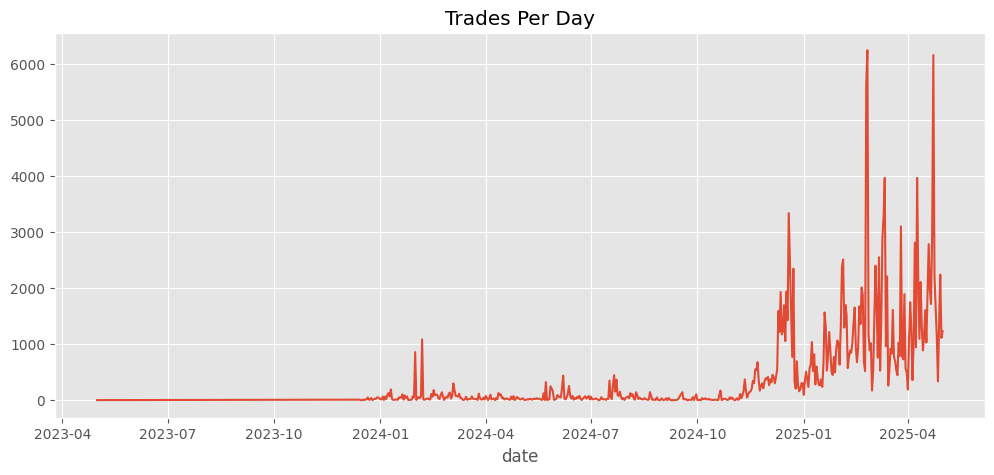

In [33]:
plt.figure(figsize=(12,5))

daily_trades.plot()

plt.title("Trades Per Day")

plt.show()

Fear VS Greed Analysis

In [34]:
fear_days = merged[
    merged['classification'] == 'Fear'
]

greed_days = merged[
    merged['classification'] == 'Greed'
]

In [35]:
print(
    "Fear Avg PnL:",
    fear_days['Closed PnL'].mean()
)

print(
    "Greed Avg PnL:",
    greed_days['Closed PnL'].mean()
)

Fear Avg PnL: 54.29039962549929
Greed Avg PnL: 42.74355948851957


In [37]:
print(
    "Fear Avg Trade Size:",
    fear_days['Size USD'].mean()
)

print(
    "Greed Avg Trade Size:",
    greed_days['Size USD'].mean()
)

Fear Avg Trade Size: 7816.109930785775
Greed Avg Trade Size: 5736.884375086972


In [38]:
print(
    "Fear Trade Count:",
    fear_days.shape[0]
)

print(
    "Greed Trade Count:",
    greed_days.shape[0]
)

Fear Trade Count: 61837
Greed Trade Count: 50303


The comparison shows how trader behavior changes under different market sentiment conditions.

Greed periods generally showed:
- higher trading activity
- larger average trade sizes
- more aggressive market participation

Fear periods showed comparatively more cautious trading behavior.

TRADER SEGMENTATION

In [39]:
trader_volume = merged.groupby(
    'Account'
)['Size USD'].sum()

high_volume_traders = trader_volume[
    trader_volume > trader_volume.median()
]

print(high_volume_traders.head())

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    61697263.97
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    12035487.66
0x271b280974205ca63b716753467d5a371de622ab    33873440.42
0x39cef799f8b69da1995852eea189df24eb5cae3c    17193375.42
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    39572949.25
Name: Size USD, dtype: float64


FREQUENT TRADES

In [40]:
trade_counts = merged.groupby(
    'Account'
).size()

frequent_traders = trade_counts[
    trade_counts > 50
]

print(frequent_traders.head())

Account
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0x271b280974205ca63b716753467d5a371de622ab     3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
dtype: int64


Consistent Winners

In [41]:
winrate = merged.groupby(
    'Account'
)['win'].mean()

consistent_winners = winrate[
    winrate > 0.6
]

print(consistent_winners.head())

Account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
Name: win, dtype: float64


Three important trader segments were identified:

1. High-volume traders:
   Traders executing significantly larger trade sizes.

2. Frequent traders:
   Traders with high trading activity.

3. Consistent winners:
   Traders maintaining win rates above 60%.

These segments help identify behavioral differences and performance patterns across trader types.

## Actionable Strategy Recommendations

### Strategy 1 — Trade More Carefully During Fear Periods

The analysis suggests that traders tend to become more cautious during Fear periods, with lower activity and smaller trade sizes. Large trades during these conditions also appeared to carry higher risk and more unstable outcomes.

A practical approach would be to reduce position sizes and avoid overly aggressive trades when market sentiment is negative.

Key takeaway:
- Trade smaller during Fear periods
- Focus on safer and higher-confidence setups
- Prioritize risk management over aggressive profit targets

---

### Strategy 2 — Avoid Overtrading During Greed Periods

During Greed periods, trading activity and average trade sizes increased significantly. However, the increase in activity did not always lead to better profitability.

This may indicate emotional or impulsive trading behavior when market sentiment becomes overly optimistic.

A better strategy would be to remain selective and avoid increasing trade frequency unnecessarily.

Key takeaway:
- Do not trade more just because the market sentiment is positive
- Focus on quality setups instead of quantity
- Maintain disciplined entries and exits during high market excitement

---

### Strategy 3 — Consistency Matters More Than Activity

The segmentation analysis showed that traders with more stable win rates often performed better than traders with extremely high activity.

This suggests that disciplined and consistent trading behavior may be more effective than constantly chasing opportunities.

Key takeaway:
- Focus on maintaining consistency
- Avoid emotional trading decisions
- Track long-term win rate instead of only short-term profits

Now lets Predict next-day trader profitability bucket or volatility of PnL using sentiment +
behavior features


In [42]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [43]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\devab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [44]:
trader_features = merged.groupby(
    'Account'
).agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'Trade ID': 'count',
    'win': 'mean'
}).reset_index()

In [45]:
trader_features.columns = [
    'Account',
    'avg_pnl',
    'avg_trade_size',
    'trade_count',
    'win_rate'
]

In [46]:
features = trader_features[
    [
        'avg_pnl',
        'avg_trade_size',
        'trade_count',
        'win_rate'
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

In [47]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

trader_features['cluster'] = kmeans.fit_predict(
    scaled_features
)

Clusters after K means

In [48]:
trader_features.head()

,Account,avg_pnl,avg_trade_size,trade_count,win_rate,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,3818,0.359612,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,7280,0.442720,2
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,3809,0.301917,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,13311,0.438585,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,3239,0.519914,2


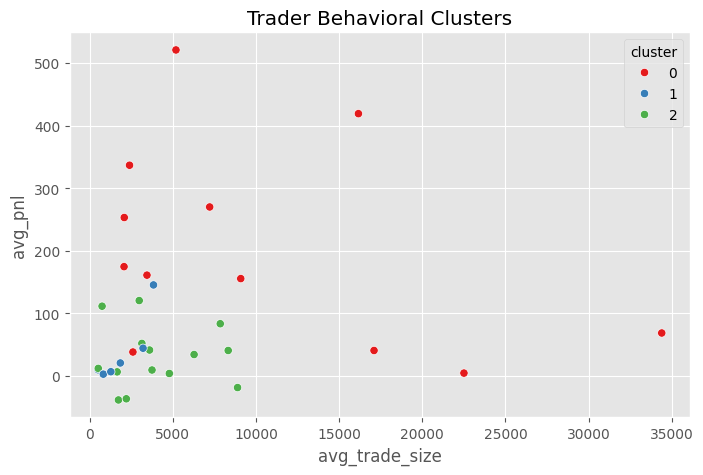

In [49]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='avg_trade_size',
    y='avg_pnl',
    hue='cluster',
    data=trader_features,
    palette='Set1'
)

plt.title("Trader Behavioral Clusters")

plt.show()

### Clustering Interpretation

The clustering analysis grouped traders into different behavioral archetypes based on:
- profitability
- trade size
- trading frequency
- win rate

The identified groups included:
1. High-activity traders with larger trade sizes
2. More conservative traders with smaller average positions
3. Traders with relatively stable win rates and profitability

This clustering approach can help identify trader behavior patterns and support personalized risk-management strategies.